In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

import config
from src.features import split_data, drop_object_cols

In [2]:
df = pd.read_parquet(config.RESULTS_PATH / 'data_features.parquet')
print(df.shape)

(590540, 460)


## train / val / test split

time-based split: rows sorted by TransactionDT ascending, then cut at 70/85%.
no random shuffling -- preserves temporal order and prevents data leakage.

train  shape: (413378, 457)  fraud rate: 0.0352
val    shape: (88581, 457)  fraud rate: 0.0343
test   shape: (88581, 457)  fraud rate: 0.0348


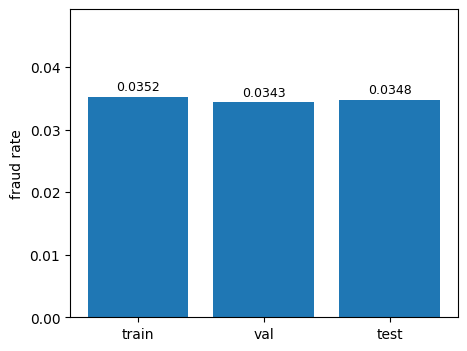

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, config.TARGET)

splits = ['train', 'val', 'test']
rates = [y_train.mean(), y_val.mean(), y_test.mean()]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(splits, rates)
ax.set_ylabel('fraud rate')
ax.set_ylim(0, max(rates) * 1.4)
for i, r in enumerate(rates):
    ax.text(i, r + max(rates) * 0.03, f'{r:.4f}', ha='center', fontsize=9)
plt.savefig(str(config.PLOTS_PATH / 'split_fraud_rates.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [4]:
X_train = drop_object_cols(X_train)
X_val   = drop_object_cols(X_val)
X_test  = drop_object_cols(X_test)

print(f'final X_train shape: {X_train.shape}')
print(f'final X_val shape:   {X_val.shape}')
print(f'final X_test shape:  {X_test.shape}')

dropping 26 original string columns
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
dropping 26 original string columns
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
dropping 26 original string columns
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
final X_train shape: (413378, 431)
final X_val shape:   (88581, 431)
final X_test shape:  (88581, 431)


## save

In [5]:
X_train.to_parquet(config.RESULTS_PATH / 'X_train.parquet', index=False)
X_val.to_parquet(config.RESULTS_PATH / 'X_val.parquet', index=False)
X_test.to_parquet(config.RESULTS_PATH / 'X_test.parquet', index=False)
y_train.to_frame().to_parquet(config.RESULTS_PATH / 'y_train.parquet', index=False)
y_val.to_frame().to_parquet(config.RESULTS_PATH / 'y_val.parquet', index=False)
y_test.to_frame().to_parquet(config.RESULTS_PATH / 'y_test.parquet', index=False)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_val:   {y_val.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (413378, 431)
X_val:   (88581, 431)
X_test:  (88581, 431)
y_train: (413378,)
y_val:   (88581,)
y_test:  (88581,)
